# 28. DBSCAN Clustering Project

## Proje Tanıtımı

Bu projede DBSCAN algoritması ile kümeleme çalışması yapılacaktır.

DBSCAN, gözetimsiz öğrenme yöntemlerinden biridir.  
K-Means algoritmasından farklı olarak küme sayısını önceden istemez.  
Veri noktalarını yoğunluklarına göre gruplar ve bazı noktaları gürültü yani outlier olarak ayırabilir.

Bu projede iki boyutlu örnek bir veri seti oluşturulacak ve DBSCAN algoritması ile kümelenecektir.

## Proje Yol Haritası

1. Gerekli kütüphanelerin içe aktarılması  
2. Örnek veri setinin oluşturulması  
3. Verilerin tabloya çevrilmesi  
4. Verilerin standartlaştırılması  
5. DBSCAN modelinin eğitilmesi  
6. Küme etiketlerinin veri setine eklenmesi  
7. Kümelerin görselleştirilmesi  
8. Gerçek sınıflarla karşılaştırma yapılması  
9. Kümeleme performansının değerlendirilmesi  
10. Model ve yardımcı dosyaların kaydedilmesi  
11. Streamlit uygulamasının oluşturulması  
12. README ve requirements dosyalarının hazırlanması  
13. Proje sonucunun yazılması

In [1]:
# Gerekli kütüphaneleri içe aktarıyoruz
import pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

## Veri Setinin Oluşturulması

Bu adımda make_moons fonksiyonu ile iki boyutlu örnek bir veri seti oluşturuyoruz.

Bu veri seti, DBSCAN algoritmasını göstermek için uygundur.  
Çünkü veri noktaları doğrusal olmayan bir yapıya sahiptir ve yoğunluk temelli kümeleme için iyi bir örnektir.

In [2]:
# DBSCAN için örnek veri seti oluşturuyoruz
X, y = make_moons(n_samples=300, noise=0.08, random_state=42)
df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])
df.head()

,Feature_1,Feature_2
0,0.658801,-0.355963
1,1.986302,-0.133490
2,-0.111623,0.455081
3,0.905008,0.266798
4,1.181619,-0.494965


## Veri Setinin İncelenmesi

Bu adımda oluşturulan veri setinin genel yapısını kontrol ediyoruz.

Veri setinde iki adet sayısal özellik bulunmaktadır.  
DBSCAN algoritması bu iki özellik üzerinden veri noktalarını yoğunluklarına göre kümelere ayıracaktır.

In [3]:
# Veri setinin genel yapısını kontrol ediyoruz
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  300 non-null    float64
 1   Feature_2  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


In [4]:
# Veri setinin temel istatistiklerini inceliyoruz
df.describe()

,Feature_1,Feature_2
count,300.000000,300.000000
mean,0.500660,0.255113
std,0.874055,0.499857
min,-1.178231,-0.628999
25%,-0.082875,-0.192738
50%,0.462349,0.254508
75%,1.073926,0.719840
max,2.214711,1.187079


## Veri Setinin Görselleştirilmesi

Bu adımda model eğitilmeden önce veri setinin dağılımını görselleştiriyoruz.

Grafik sayesinde veri noktalarının genel yapısını ve olası kümeleri daha rahat görebiliriz.

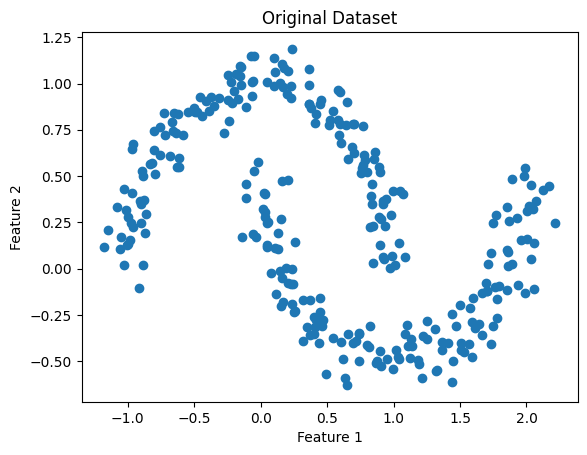

In [5]:
# Ham veri setini görselleştiriyoruz
plt.scatter(df["Feature_1"], df["Feature_2"])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Dataset")
plt.show()

## Verilerin Standartlaştırılması

Bu adımda verileri standartlaştırıyoruz.

DBSCAN algoritması mesafe temelli çalıştığı için değişkenlerin aynı ölçeğe getirilmesi önemlidir.  
Bu işlem, modelin daha dengeli ve doğru kümeleme yapmasına yardımcı olur.

In [6]:
# Verileri standartlaştırıyoruz
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## DBSCAN Modelinin Eğitilmesi

Bu adımda DBSCAN algoritmasını kullanarak veri noktalarını kümelere ayırıyoruz.

DBSCAN algoritmasında iki önemli parametre vardır:

- eps: Bir noktanın komşu sayılması için maksimum mesafe
- min_samples: Bir bölgenin yoğun kabul edilmesi için gereken minimum nokta sayısı

DBSCAN ayrıca bazı noktaları gürültü olarak işaretleyebilir. Gürültü noktaları genellikle -1 etiketi ile gösterilir.

In [7]:
# DBSCAN modelini eğitiyoruz
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

In [8]:
# Oluşan küme etiketlerini kontrol ediyoruz
set(clusters)

{np.int64(0), np.int64(1)}

## Küme Etiketlerinin Veri Setine Eklenmesi

Bu adımda DBSCAN algoritmasının oluşturduğu küme etiketlerini veri setine ekliyoruz.

Böylece her veri noktasının hangi kümeye ait olduğunu tablo üzerinde görebiliriz.

In [9]:
# DBSCAN tarafından oluşturulan küme etiketlerini veri setine ekliyoruz
df["Cluster"] = clusters
df.head()

,Feature_1,Feature_2,Cluster
0,0.658801,-0.355963,0
1,1.986302,-0.133490,0
2,-0.111623,0.455081,0
3,0.905008,0.266798,1
4,1.181619,-0.494965,0


## DBSCAN Kümelerinin Görselleştirilmesi

Bu adımda DBSCAN algoritmasının oluşturduğu kümeleri görselleştiriyoruz.

Grafikte her renk farklı bir kümeyi temsil etmektedir.  
DBSCAN, veri noktalarını yoğunluklarına göre gruplandırdığı için doğrusal olmayan veri yapılarında başarılı sonuçlar verebilir.

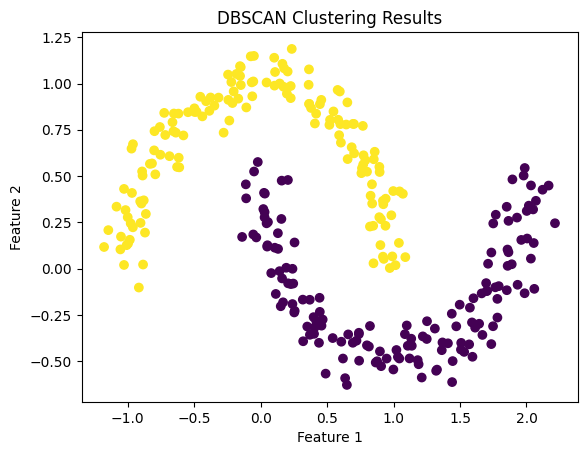

In [10]:
# DBSCAN kümeleme sonuçlarını görselleştiriyoruz
plt.scatter(df["Feature_1"], df["Feature_2"], c=df["Cluster"])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering Results")
plt.show()

## Görselleştirme Yorumu

Grafikte DBSCAN algoritmasının veri noktalarını iki ana kümeye ayırdığı görülmektedir.

Bu sonuç, DBSCAN algoritmasının doğrusal olmayan yapılarda etkili şekilde çalışabildiğini göstermektedir.  
K-Means gibi merkez temelli algoritmaların zorlanabileceği veri yapılarında DBSCAN daha esnek sonuçlar üretebilir.

## Gerçek Sınıflarla Karşılaştırma

Bu adımda DBSCAN algoritmasının oluşturduğu kümeleri, veri seti oluşturulurken elde edilen gerçek sınıflarla karşılaştırıyoruz.

Burada dikkat edilmesi gereken nokta şudur:  
Küme numaraları doğrudan gerçek sınıf isimleri anlamına gelmez.

Ama yine de modelin veriyi ne kadar doğru grupladığını görmek için gerçek sınıflarla karşılaştırma yapabiliriz.

In [11]:
# Gerçek sınıf etiketlerini veri setine ekliyoruz
df["Actual_Class"] = y
df.head()

,Feature_1,Feature_2,Cluster,Actual_Class
0,0.658801,-0.355963,0,1
1,1.986302,-0.133490,0,1
2,-0.111623,0.455081,0,1
3,0.905008,0.266798,1,0
4,1.181619,-0.494965,0,1


In [12]:
# Gerçek sınıflar ile DBSCAN kümelerini karşılaştırıyoruz
pd.crosstab(df["Actual_Class"], df["Cluster"])

Cluster,0,1
Actual_Class,,
0,0,150
1,150,0


## Kümeleme Performansının Ölçülmesi

Bu adımda DBSCAN sonucunu Adjusted Rand Score ile değerlendiriyoruz.

Adjusted Rand Score, modelin oluşturduğu kümelerin gerçek sınıflarla ne kadar benzer olduğunu gösterir.  
Skor 1'e yaklaştıkça sonuç daha başarılı kabul edilir.

In [13]:
# Kümeleme başarısını Adjusted Rand Score ile ölçüyoruz
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(df["Actual_Class"], df["Cluster"])

1.0

## Model Dosyalarının Kaydedilmesi

DBSCAN algoritması yeni gelen veriler için doğrudan predict fonksiyonu kullanmaz.

Bu nedenle uygulamada kullanmak için DBSCAN modeli, scaler nesnesi, standartlaştırılmış veri ve küme etiketleri kaydedilecektir.  
Yeni girilen veri önce standartlaştırılacak, sonra en yakın veri noktasının kümesine atanacaktır.

In [14]:

# Model ve yardımcı nesneleri kaydediyoruz
import joblib
joblib.dump(dbscan, "dbscan_model.pkl")
joblib.dump(scaler, "dbscan_scaler.pkl")
joblib.dump(X_scaled, "dbscan_scaled_data.pkl")
joblib.dump(clusters, "dbscan_clusters.pkl")

['dbscan_clusters.pkl']

In [15]:
# Kaydedilen model dosyalarını kontrol ediyoruz
import os
[f for f in os.listdir() if f.endswith(".pkl")]

['dbscan_scaler.pkl',
 'dbscan_model.pkl',
 'dbscan_clusters.pkl',
 'dbscan_scaled_data.pkl']

## Streamlit Uygulamasının Oluşturulması

Bu adımda DBSCAN projesi için basit bir Streamlit uygulaması oluşturuyoruz.

DBSCAN algoritması yeni veriler için doğrudan predict fonksiyonu kullanmadığı için uygulamada farklı bir yöntem kullanacağız.  
Kullanıcının girdiği yeni veri önce standartlaştırılacak, sonra eğitim verisindeki en yakın noktaya bakılarak o noktanın kümesi tahmin sonucu olarak gösterilecektir.

In [16]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

scaler = joblib.load("dbscan_scaler.pkl")
X_scaled = joblib.load("dbscan_scaled_data.pkl")
clusters = joblib.load("dbscan_clusters.pkl")

st.title("DBSCAN Clustering Project")
st.write("This app assigns a new data point to a DBSCAN cluster using the nearest trained data point.")

feature_1 = st.slider("Feature 1", -2.0, 3.0, 0.0)
feature_2 = st.slider("Feature 2", -1.5, 2.0, 0.0)

data = pd.DataFrame([[feature_1, feature_2]], columns=["Feature_1", "Feature_2"])
scaled_data = scaler.transform(data)

distances = np.linalg.norm(X_scaled - scaled_data, axis=1)
nearest_index = np.argmin(distances)
cluster = clusters[nearest_index]

st.subheader("Prediction Result")
st.write("Predicted Cluster:", int(cluster))

Writing app.py


## Requirements Dosyasının Oluşturulması

Bu adımda uygulamanın çalışması için gerekli kütüphaneleri requirements.txt dosyasına yazıyoruz.

Bu dosya, projenin Hugging Face Spaces veya GitHub üzerinde çalıştırılması için gereklidir.

In [17]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib
matplotlib

Writing requirements.txt


## README Dosyasının Oluşturulması

Bu adımda proje için README.md dosyası oluşturuyoruz.

README dosyası, projenin amacını, kullanılan yöntemi, oluşturulan dosyaları ve Streamlit uygulamasının nasıl çalıştığını açıklar.


# DBSCAN Clustering Project

## Project Description

This project applies DBSCAN Clustering to a two-dimensional make_moons dataset.

DBSCAN is an unsupervised machine learning algorithm. Unlike K-Means, it does not require the number of clusters to be selected before training. It groups data points according to density and can also detect noise points.

## Dataset

The dataset was created using the make_moons function from Scikit-learn.

It contains two numerical features:

- Feature_1
- Feature_2

## Method

The project includes the following steps:

1. Creating a sample dataset
2. Visualizing the original data
3. Standardizing the data
4. Training the DBSCAN model
5. Adding cluster labels to the dataset
6. Visualizing DBSCAN clusters
7. Comparing clusters with actual classes
8. Evaluating the result with Adjusted Rand Score
9. Saving the model and helper files
10. Creating a Streamlit application

## Saved Files

The following files were created:

- dbscan_model.pkl
- dbscan_scaler.pkl
- dbscan_scaled_data.pkl
- dbscan_clusters.pkl
- app.py
- requirements.txt

## Streamlit App

The Streamlit app allows users to enter two feature values.

Since DBSCAN does not directly support prediction for new data, the app assigns the new point to the cluster of the nearest trained data point.

## Conclusion

DBSCAN successfully separated the make_moons dataset into two clusters.

This project shows that DBSCAN can work well on non-linear datasets where center-based methods such as K-Means may not perform as effectively.

## Proje Dosyalarının Kontrol Edilmesi

Bu adımda proje için gerekli dosyaların oluşup oluşmadığını kontrol ediyoruz.

Model dosyaları, Streamlit uygulaması, requirements dosyası ve README dosyası eksiksiz olmalıdır.

In [18]:
# Proje dosyalarının eksiksiz oluşup oluşmadığını kontrol ediyoruz
import os

required = [
    "app.py",
    "requirements.txt",
    "README.md",
    "dbscan_model.pkl",
    "dbscan_scaler.pkl",
    "dbscan_scaled_data.pkl",
    "dbscan_clusters.pkl"
]

missing = [f for f in required if not os.path.exists(f)]

"All files are ready." if not missing else f"Missing files: {missing}"

"Missing files: ['README.md']"